In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pytz
import os
from glob import glob
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression
from itertools import product
from sklearn.linear_model import LogisticRegression

In [6]:
root="/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/"  # Change to user directory
fldr=root+"supportingData/"
dat = np.load(fldr+"rmobilizations.npy")
# For full dataset, load raw mobilizations (rmobilizations.npy)
print(dat.shape)
mobilizations=dat[0,:]
flows=dat[1,:]
omega0=dat[2,:]
stays=dat[3,:]

(4, 48603)


In [7]:
mobilizations.sum()

814.0

In [8]:
print(mobilizations[(omega0 > 10**1)].mean())
print(mobilizations[(omega0 < 10**-2)].mean())

0.035531370038412294
0.010378510378510378


/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['fit_intercept']
  warnings.warn(msg, ValueWarning)
/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['fit_intercept']
  warnings.warn(msg, ValueWarning)


Optimization terminated successfully.
         Current function value: 0.074674
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                48603
Model:                          Logit   Df Residuals:                    48600
Method:                           MLE   Df Model:                            2
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.1225
Time:                        18:26:14   Log-Likelihood:                -3629.4
converged:                       True   LL-Null:                       -4136.0
Covariance Type:            nonrobust   LLR p-value:                9.564e-221
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1090      0.015      7.385      0.000       0.080       0.138
x2            -0.0746      0.

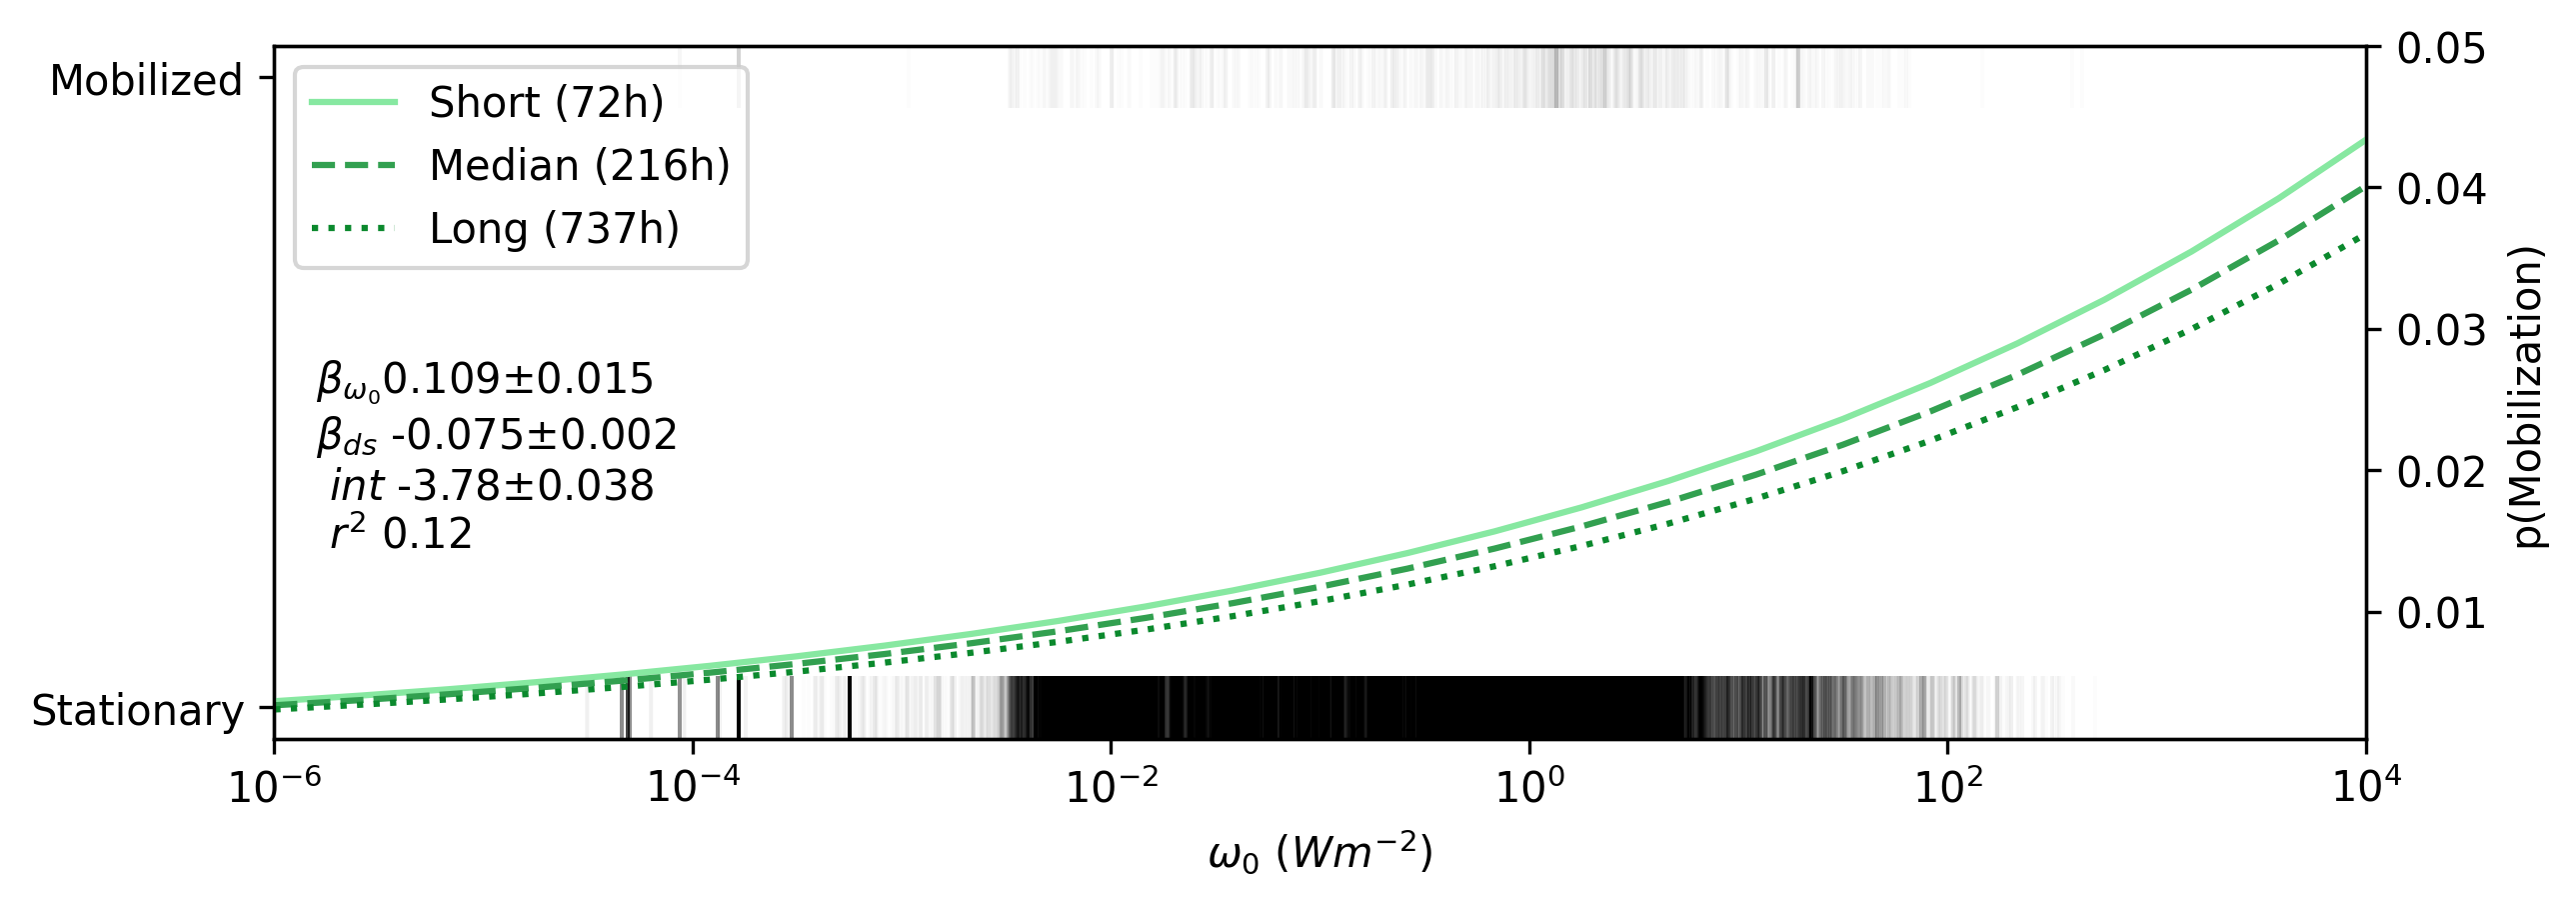

In [9]:
plot=True
low,high=1e-6,1e4
if plot:
    fig,ax=plt.subplots(1,1,figsize=(9,3),dpi=300)        
    axb=ax.twinx()
R = np.arange(np.log(1e-4),np.log(1e3),1)

if plot:
    ax.plot(omega0,mobilizations.astype(int),color='k',marker="|",ms=15,ls='none',alpha=0.01)
    ax.set_xscale('log')
    ax.set_yticks([0,1])
    ax.set_yticklabels(["Stationary","Mobilized"])
    ax.set_xlabel("$\omega_0$ ($W m^{-2}$)")

# Without lodging
no_lodging=False
if no_lodging:
    X=np.stack((np.log(omega0),np.ones_like(omega0))).T
    y=mobilizations.astype(int)
    
    model = sm.Logit(y,X,missing="drop").fit()
    print(model.summary())
    print(dir(model))
    
    X_plot=np.logspace(np.log(low),np.log(high),25,base=np.exp(1))
    cs="#87e8a1 #32a050 #0b892d".split()
    X_pred=np.stack((X_plot,np.exp(1)*np.ones_like(X_plot))).T
    y_prob=model.predict(np.log(X_pred))
    
    if plot:
        axb.plot(X_plot,y_prob,ls='--',color='b',label="No lodging")        
    
    
    if plot:
        axb.text(0.20,0.55,r"$\beta_{\omega_0}$"+"{:0.3f}$\pm${:0.3f}\n".format(model.params[0],model.bse[0])
                 +"$int$ {:0.2f}$\pm${:0.3f} \n $r^2$ {:0.2f}".format(model.params[1],model.bse[1],model.prsquared),
                transform=ax.transAxes,fontsize=8,va="top")

# With lodging
X=np.stack((np.log(omega0),np.log(stays),np.ones_like(omega0))).T
y=mobilizations.astype(int)

model = sm.Logit(y,X,missing="drop",fit_intercept=True).fit()
print(model.summary())

durations=stays[mobilizations==1]
durations=durations[durations>1]
q1,q2,q3=np.quantile(durations,[0.25,0.5,0.75])
print(q1,q2,q3)

X_plot=np.logspace(np.log(low),np.log(high),25,base=np.exp(1))
cs="#87e8a1 #32a050 #0b892d".split()
for n,c,q,l in zip("Short ({:0.0f}h),Median ({:0.0f}h),Long ({:0.0f}h)".format(q1,q2,q3).split(','),cs,[q1,q2,q3],["-","--",":"]):
    X_pred=np.stack((X_plot,q*np.ones_like(X_plot),np.exp(1)*np.ones_like(X_plot))).T
    y_prob=model.predict(np.log(X_pred))

    if plot:
        axb.plot(X_plot,y_prob,ls=l,color=c,label=n)        

if plot:
    axb.text(0.02,0.55,r"$\beta_{\omega_0}$"+"{:0.3f}$\pm${:0.3f}\n".format(model.params[0],model.bse[0])
             +r"$\beta_{ds}$"
             +" {:0.3f}$\pm${:0.3f} \n $int$ {:0.2f}$\pm${:0.3f} \n $r^2$ {:0.2f}".format(model.params[1],model.bse[1],model.params[2],model.bse[2],
                                                                                                   model.prsquared),
            transform=ax.transAxes,fontsize=10,va="top")

    axb.set_ylabel("p(Mobilization)")
    axb.set_ylim((1e-3,5e-2))
    ax.set_xlim((low,high))
    axb.legend(loc=2)